# EDA & Time Series Analysis

Companion notebook to `src/visualization/eda.py` and `src/visualization/time_series_analysis.py`.
Runs the exact same functions used by the pipeline/dashboard, so results here always match production.

In [1]:
import sys
sys.path.insert(0, "..")

from src.data.ingestion import load_train
from src.visualization.eda import compute_summary_stats, run_eda
from src.visualization.time_series_analysis import run_time_series_analysis

df = load_train()
df.head()

2026-07-11 00:55:23 | INFO     | src.data.ingestion | Loading training data from /home/claude/work/Retail-Demand-Forecasting/data/raw/train.csv


2026-07-11 00:55:24 | INFO     | src.data.ingestion | Loaded 913000 training rows spanning 2013-01-01 00:00:00 to 2017-12-31 00:00:00


,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10


## Summary Statistics

In [2]:
stats = compute_summary_stats(df)
stats

{'n_rows': 913000,
 'n_stores': 10,
 'n_items': 50,
 'n_series': 500,
 'date_min': '2013-01-01',
 'date_max': '2017-12-31',
 'sales_mean': 52.250286966046005,
 'sales_std': 28.801143603517097,
 'sales_min': 0,
 'sales_max': 231,
 'sales_median': 47.0}

## Run Full EDA Suite (saves charts to images/, stats to reports/)

In [3]:
eda_stats = run_eda()
eda_stats

2026-07-11 00:55:24 | INFO     | src.data.ingestion | Loading training data from /home/claude/work/Retail-Demand-Forecasting/data/raw/train.csv


2026-07-11 00:55:25 | INFO     | src.data.ingestion | Loaded 913000 training rows spanning 2013-01-01 00:00:00 to 2017-12-31 00:00:00


2026-07-11 00:55:25 | INFO     | src.visualization.eda | EDA summary stats: {'n_rows': 913000, 'n_stores': 10, 'n_items': 50, 'n_series': 500, 'date_min': '2013-01-01', 'date_max': '2017-12-31', 'sales_mean': 52.250286966046005, 'sales_std': 28.801143603517097, 'sales_min': 0, 'sales_max': 231, 'sales_median': 47.0}


2026-07-11 00:55:27 | INFO     | matplotlib.category | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-07-11 00:55:27 | INFO     | matplotlib.category | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-07-11 00:55:27 | INFO     | matplotlib.category | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-07-11 00:55:27 | INFO     | matplotlib.category | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-07-11 00:55:27 | INFO     | src.visualization.eda | EDA plots saved to /home/claude/work/Retail-Demand-Forecasting/images


{'n_rows': 913000,
 'n_stores': 10,
 'n_items': 50,
 'n_series': 500,
 'date_min': '2013-01-01',
 'date_max': '2017-12-31',
 'sales_mean': 52.250286966046005,
 'sales_std': 28.801143603517097,
 'sales_min': 0,
 'sales_max': 231,
 'sales_median': 47.0}

## Quick Look: Overall Trend

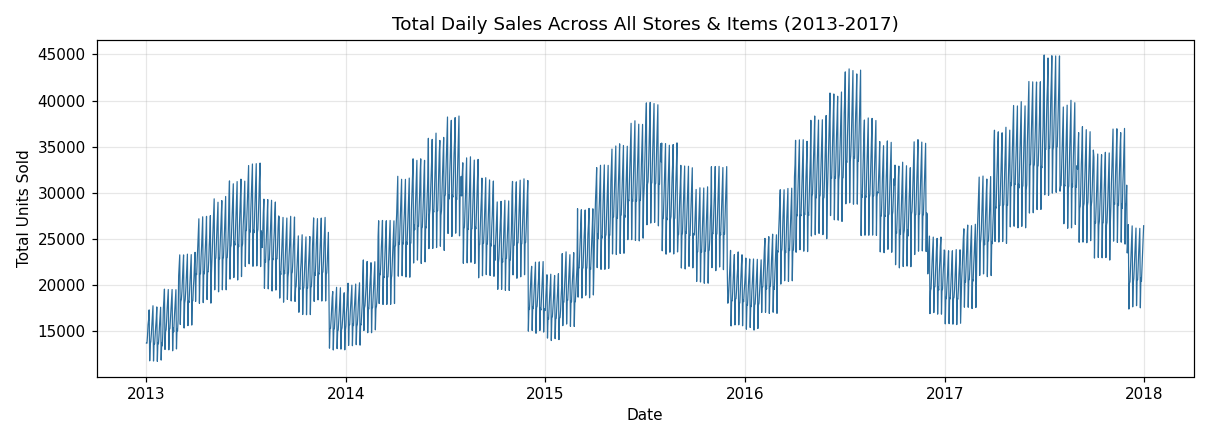

In [4]:
from IPython.display import Image
Image(filename="../images/eda_overall_trend.png")

## Quick Look: Monthly Seasonality

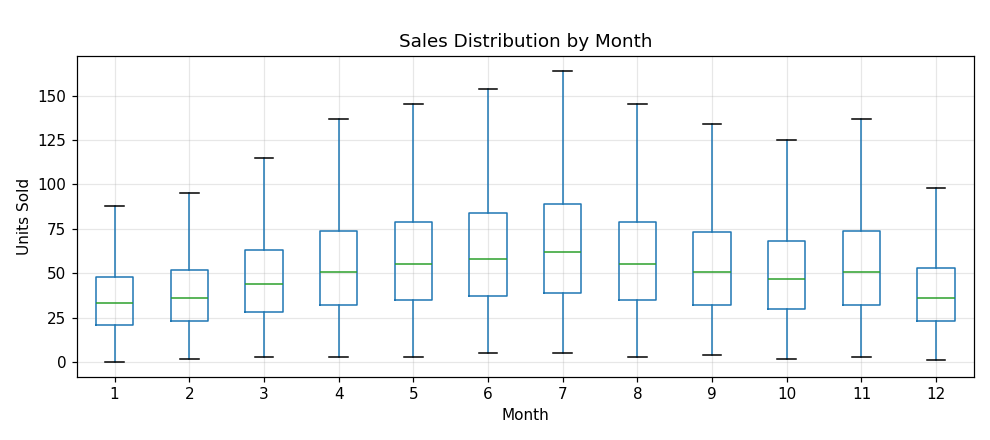

In [5]:
Image(filename="../images/eda_monthly_seasonality.png")

## Time Series Analysis: STL Decomposition + Stationarity Tests

In [6]:
ts_results = run_time_series_analysis()
ts_results

2026-07-11 00:55:27 | INFO     | src.data.ingestion | Loading training data from /home/claude/work/Retail-Demand-Forecasting/data/raw/train.csv


2026-07-11 00:55:28 | INFO     | src.data.ingestion | Loaded 913000 training rows spanning 2013-01-01 00:00:00 to 2017-12-31 00:00:00


2026-07-11 00:55:36 | INFO     | src.visualization.time_series_analysis | Time series analysis results: {'aggregate_adf': {'adf_statistic': -3.060244118701342, 'p_value': 0.02963864926884404, 'is_stationary_at_5pct': True}, 'example_series_adf': {'adf_statistic': -3.157670556332827, 'p_value': 0.022569380626570063, 'is_stationary_at_5pct': True}}


{'aggregate_adf': {'adf_statistic': -3.060244118701342,
  'p_value': 0.02963864926884404,
  'is_stationary_at_5pct': True},
 'example_series_adf': {'adf_statistic': -3.157670556332827,
  'p_value': 0.022569380626570063,
  'is_stationary_at_5pct': True}}

## Quick Look: STL Decomposition (Aggregate)

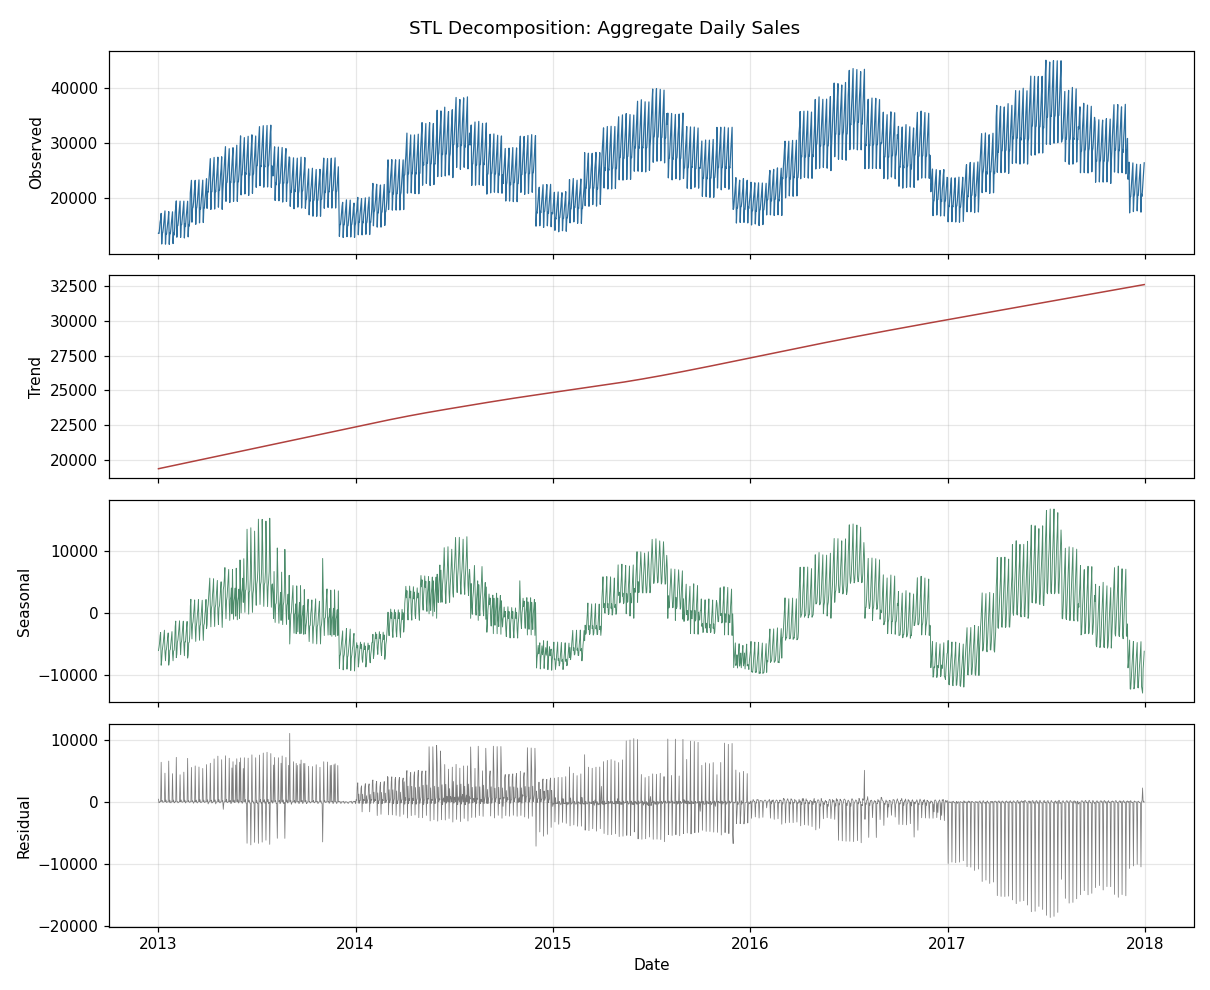

In [7]:
Image(filename="../images/stl_aggregate.png")

## Interpretation

- Clear upward **trend** across 2013-2017.
- Strong **yearly seasonality** (summer peak, winter trough) and weekly seasonality (weekends > weekdays).
- The Augmented Dickey-Fuller test rejects the unit-root null for both the aggregate and an example series,
  supporting the use of lag/rolling features directly (see `src/features/lag_features.py`) rather than differencing.

See `docs/results.md` for the full write-up.